## Project 3 -- Time series analysis

In [ ]:
!pip install -q kagglehub tslearn pandas numpy matplotlib

In [ ]:
# --- Imports ---
import kagglehub
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tslearn.metrics import cdist_dtw

# Download latest version of the data
path = kagglehub.dataset_download("sergionefedov/patient-records-100k-patients-15-conditions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'patient-records-100k-patients-15-conditions' dataset.
Path to dataset files: /kaggle/input/patient-records-100k-patients-15-conditions


In [ ]:
TABLES = ["diagnoses", "lab_results", "medications", "outcomes", "patients"]

dfs = {}
for table in TABLES:
    filepath = f"{path}/{table}.csv"
    dfs[table] = pd.read_csv(filepath)
    print(f"  {table:20s} {dfs[table].shape[0]:>8,} rows  x  {dfs[table].shape[1]} cols")

# Unpack to named variables for convenience
diagnoses_df   = dfs["diagnoses"]
lab_results_df = dfs["lab_results"]
medications_df = dfs["medications"]
outcomes_df    = dfs["outcomes"]
patients_df    = dfs["patients"]

# Test a dataframe
patients_df.head()

  diagnoses             274,592 rows  x  8 cols
  lab_results          2,827,722 rows  x  10 cols
  medications           364,174 rows  x  10 cols
  outcomes               11,001 rows  x  12 cols
  patients              100,000 rows  x  28 cols


,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66,M,23.5,148,81,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73,F,28.1,118,83,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86,F,30.6,156,81,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0


### Step 1: Data Wrangling

In [ ]:
# --- Step 1: Filter to Type 2 Diabetes rows ---
t2d_ids = set(patients_df.loc[patients_df['dx_type2_diabetes'] == 1, 'patient_id'])
print(f"Type 2 diabetic patients (patients.csv flag): {len(t2d_ids):,}")

# --- Step 2: Filter lab results to HbA1c only ---
hba1c_df = lab_results_df[lab_results_df['test_name'] == 'HbA1c'].copy()
hba1c_df['test_date'] = pd.to_datetime(hba1c_df['test_date'])
print(f"Total HbA1c records (all patients):           {len(hba1c_df):,}")
print(f"Unique patients with any HbA1c:               {hba1c_df['patient_id'].nunique():,}")

# --- Step 3: Restrict to T2D cohort ---
hba1c_df = hba1c_df[hba1c_df['patient_id'].isin(t2d_ids)].copy()
print(f"HbA1c records for T2D patients:               {len(hba1c_df):,}")
print(f"Unique T2D patients with HbA1c:               {hba1c_df['patient_id'].nunique():,}")

# --- Step 4: Sort chronologically within each patient ---
hba1c_df = hba1c_df.sort_values(['patient_id', 'test_date']).reset_index(drop=True)

hba1c_df.head()

Type 2 diabetic patients (patients.csv flag): 15,750
Total HbA1c records (all patients):           41,853
Unique patients with any HbA1c:               16,337
HbA1c records for T2D patients:               40,362
Unique T2D patients with HbA1c:               15,750


,patient_id,test_date,test_name,value,unit,reference_low,reference_high,flag,is_abnormal,delta_from_normal
0,P0000002,2018-02-17,HbA1c,9.992,%,4.0,5.6,high,1,5.192
1,P0000002,2018-07-14,HbA1c,8.772,%,4.0,5.6,high,1,3.972
2,P0000002,2019-08-08,HbA1c,9.350,%,4.0,5.6,high,1,4.550
3,P0000002,2020-09-24,HbA1c,7.598,%,4.0,5.6,high,1,2.798
4,P0000002,2023-05-07,HbA1c,6.128,%,4.0,5.6,high,1,1.328


In [ ]:
# --- Step 5: Apply inclusion criteria ---
# Compute per-patient summary stats needed for filtering
patient_stats = (
    hba1c_df
    .groupby('patient_id')['test_date']
    .agg(n_measurements='count', first_date='min', last_date='max')
    .assign(span_days=lambda x: (x['last_date'] - x['first_date']).dt.days)
)

# --- Criteria ---
MIN_MEASUREMENTS = 4    # Picking 4 to make computations quicker
MIN_SPAN_DAYS    = 365  # ~12 months

eligible_ids = patient_stats[
    (patient_stats['n_measurements'] >= MIN_MEASUREMENTS) &
    (patient_stats['span_days'] >= MIN_SPAN_DAYS)
].index

hba1c_cohort = hba1c_df[hba1c_df['patient_id'].isin(eligible_ids)].copy()

print(f"\n--- Inclusion criteria: ≥{MIN_MEASUREMENTS} measurements, span ≥{MIN_SPAN_DAYS} days ---")
print(f"Patients meeting criteria:  {len(eligible_ids):,}")
print(f"HbA1c records in cohort:    {len(hba1c_cohort):,}")

# --- Step 6: Sanity check ---
print("\nMeasurements per patient:")
print(patient_stats.loc[eligible_ids, 'n_measurements'].describe().round(1))
print("\nSpan in days per patient:")
print(patient_stats.loc[eligible_ids, 'span_days'].describe().round(1))

hba1c_cohort.head(10)


--- Inclusion criteria: ≥4 measurements, span ≥365 days ---
Patients meeting criteria:  3,668
HbA1c records in cohort:    17,278

Measurements per patient:
count    3668.0
mean        4.7
std         1.0
min         4.0
25%         4.0
50%         4.0
75%         5.0
max        10.0
Name: n_measurements, dtype: float64

Span in days per patient:
count    3668.0
mean     1654.1
std       472.2
min       384.0
25%      1332.8
50%      1697.0
75%      2022.0
max      2549.0
Name: span_days, dtype: float64


,patient_id,test_date,test_name,value,unit,reference_low,reference_high,flag,is_abnormal,delta_from_normal
0,P0000002,2018-02-17,HbA1c,9.992,%,4.0,5.6,high,1,5.192
1,P0000002,2018-07-14,HbA1c,8.772,%,4.0,5.6,high,1,3.972
2,P0000002,2019-08-08,HbA1c,9.350,%,4.0,5.6,high,1,4.550
3,P0000002,2020-09-24,HbA1c,7.598,%,4.0,5.6,high,1,2.798
4,P0000002,2023-05-07,HbA1c,6.128,%,4.0,5.6,high,1,1.328
13,P0000035,2019-07-04,HbA1c,9.215,%,4.0,5.6,high,1,4.415
14,P0000035,2020-01-03,HbA1c,6.207,%,4.0,5.6,high,1,1.407
15,P0000035,2020-02-26,HbA1c,9.904,%,4.0,5.6,high,1,5.104
16,P0000035,2020-04-19,HbA1c,7.148,%,4.0,5.6,high,1,2.348
17,P0000035,2020-11-17,HbA1c,9.944,%,4.0,5.6,high,1,5.144


### Data Exploration

In [ ]:
# --- Check columns and data types ---
print("="*60)
print("Dataset validation")
print("="*60)

zero_feature_check = ['value', 'test_date', 'is_abnormal']

for col in zero_feature_check:
  print(f"{col} zero values: {(hba1c_cohort[col] == 0).sum()}")
print("="*60)
print("HbA1c Columns")
print("="*60)
print(hba1c_cohort.dtypes)


Dataset validation
value zero values: 0
test_date zero values: 0
is_abnormal zero values: 0
HbA1c Columns
patient_id                   object
test_date            datetime64[ns]
test_name                    object
value                       float64
unit                         object
reference_low               float64
reference_high              float64
flag                         object
is_abnormal                   int64
delta_from_normal           float64
dtype: object


### Time Series Preparation

In [ ]:
# Number of evenly-spaced points each series will be interpolated onto.
N_TIMEPOINTS = 10
def interpolate_series(group):
    """
    Takes one patient's sorted HbA1c records and returns a fixed-length array.

    Time is mapped to [0, 1] (relative position in the observation window)
    so that a patient with 1 year of data and one with 5 years are both
    represented on the same scale. This means clustering captures *shape*
    (trajectory pattern) not *duration*.
    """
    # Average duplicate measurements on the same date before interpolating.
    # numpy.interp requires strictly increasing x values.
    group = group.groupby('test_date')['value'].mean().reset_index()
    group = group.sort_values('test_date')

    dates  = group['test_date'].values
    values = group['value'].values

    # Days elapsed since the patient's first measurement
    days   = (dates - dates[0]).astype('timedelta64[D]').astype(float)
    span   = days[-1]
    if span == 0:
        # All measurements on the same day — can't build a trajectory
        return None
    # Normalize time axis to [0, 1]
    t_norm = days / span

    # Linear interpolation onto a uniform grid of N_TIMEPOINTS points.
    # Linear (not spline) because HbA1c data is sparse — higher-order
    # interpolation would create artificial wiggles between real points.
    grid   = np.linspace(0, 1, N_TIMEPOINTS)
    series = np.interp(grid, t_norm, values)

    return series
# --- Build the raw series matrix ---
series_dict = {}
for pid, group in hba1c_cohort.groupby('patient_id'):
    s = interpolate_series(group)
    if s is not None:
        series_dict[pid] = s

patient_ids = np.array(list(series_dict.keys()))
X_raw       = np.array(list(series_dict.values()))   # shape: (n_patients, N_TIMEPOINTS)

print(f"Patients in matrix: {len(patient_ids):,}")
print(f"Raw matrix shape:   {X_raw.shape}")
# --- Z-normalize each series individually ---
# Subtracting each patient's own mean and dividing by their own std means
# clustering will group patients by *trajectory shape*, not by absolute
# HbA1c level. A patient stable at 9% and one stable at 7% would otherwise
# look far apart even though both are clinically "stable poorly controlled".
X_mean = X_raw.mean(axis=1, keepdims=True)
X_std  = X_raw.std(axis=1, keepdims=True)

# Replace std=0 with 1 to avoid division by zero for perfectly flat series
X_std[X_std == 0] = 1.0

X_znorm = (X_raw - X_mean) / X_std

# --- Reshape to tslearn's expected format: (n_series, n_timepoints, n_features) ---
# The trailing 1 means we have one feature (HbA1c value) per timepoint.
X = X_znorm[:, :, np.newaxis]

print(f"tslearn-ready shape: {X.shape}")
print(f"\nRaw HbA1c value stats across all patients and timepoints:\n")
print(pd.DataFrame(X_raw, columns=[f"t{i}" for i in range(N_TIMEPOINTS)]).describe().round(2))

Patients in matrix: 3,668
Raw matrix shape:   (3668, 10)
tslearn-ready shape: (3668, 10, 1)

Raw HbA1c value stats across all patients and timepoints:

            t0       t1       t2       t3       t4       t5       t6       t7  \
count  3668.00  3668.00  3668.00  3668.00  3668.00  3668.00  3668.00  3668.00   
mean      8.47     8.49     8.49     8.50     8.50     8.50     8.50     8.51   
std       1.42     1.16     1.14     1.15     1.16     1.16     1.16     1.16   
min       6.00     6.01     6.00     6.06     6.04     6.02     6.02     6.04   
25%       7.23     7.61     7.63     7.64     7.59     7.58     7.60     7.60   
50%       8.45     8.49     8.49     8.51     8.52     8.52     8.50     8.50   
75%       9.67     9.40     9.36     9.36     9.37     9.42     9.41     9.41   
max      11.00    10.97    10.96    10.98    10.96    10.96    10.95    10.98   

            t8       t9  
count  3668.00  3668.00  
mean      8.51     8.51  
std       1.16     1.44  
min       6.06

### Visualization: Interpolation Check & Trajectory Preview (EDA)

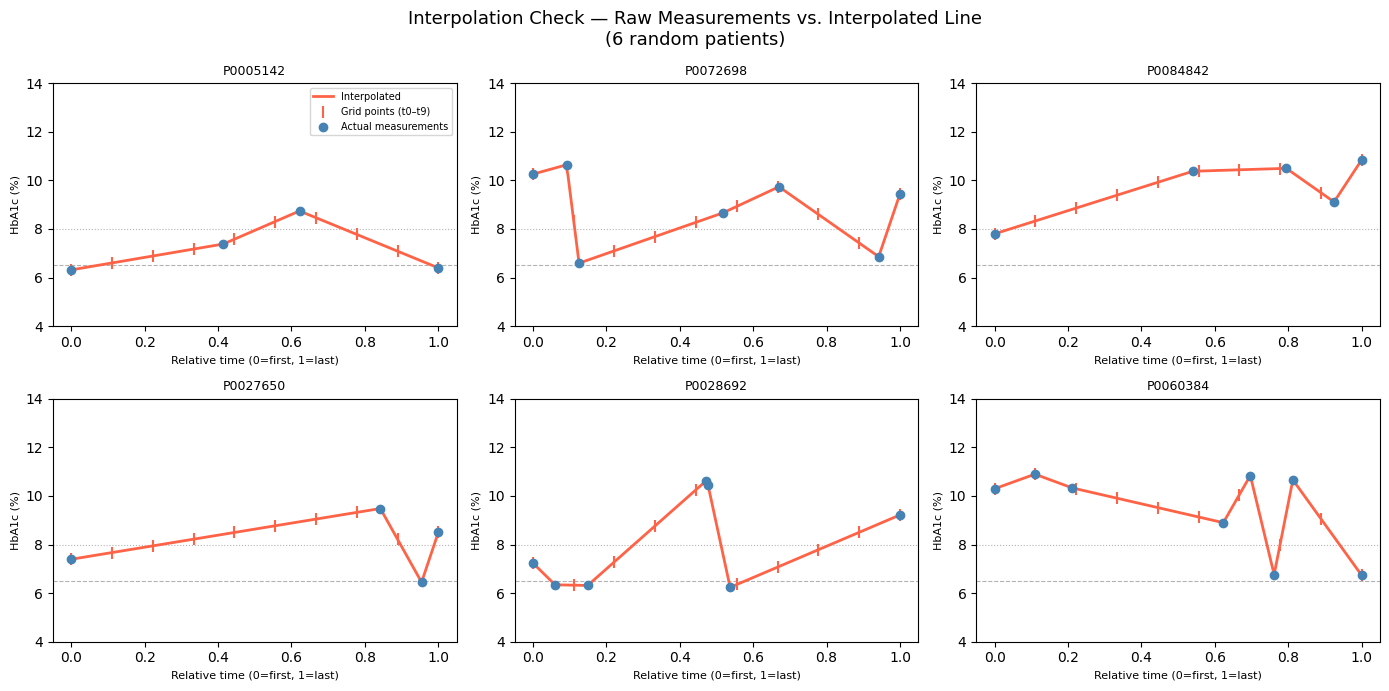

In [ ]:
# --- Plot 1: Test Interpolation ---
np.random.seed(42)
# Pick 6 random patients and show their actual measurements (scatter)
# alongside the interpolated line (solid). If the line doesn't pass through
# the dots, something is wrong with the interpolation.

sample_ids = np.random.choice(patient_ids, size=6, replace=False)
fine_grid    = np.linspace(0, 1, 200)
cluster_grid = np.linspace(0, 1, N_TIMEPOINTS)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Interpolation Check — Raw Measurements vs. Interpolated Line\n(6 random patients)", fontsize=13)

for ax, pid in zip(axes.flat, sample_ids):
    group = hba1c_cohort[hba1c_cohort['patient_id'] == pid].copy()
    group = group.groupby('test_date')['value'].mean().reset_index().sort_values('test_date')

    days   = (group['test_date'].values - group['test_date'].values[0]).astype('timedelta64[D]').astype(float)
    t_norm = days / days[-1]
    values = group['value'].values

    # Draw the interpolated line at high resolution so it visually passes
    # through every measurement dot
    fine_interp = np.interp(fine_grid, t_norm, values)

    # Mark where the 10 clustering grid points fall on this line
    cluster_interp = np.interp(cluster_grid, t_norm, values)

    ax.plot(fine_grid, fine_interp, color='tomato', linewidth=2, label='Interpolated', zorder=3)
    ax.scatter(cluster_grid, cluster_interp, color='tomato', marker='|', s=80, zorder=4, label='Grid points (t0–t9)')
    ax.scatter(t_norm, values, color='steelblue', zorder=5, label='Actual measurements')
    ax.axhline(y=6.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(y=8.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(pid, fontsize=9)
    ax.set_xlabel("Relative time (0=first, 1=last)", fontsize=8)
    ax.set_ylabel("HbA1c (%)", fontsize=8)
    ax.set_ylim(4, 14)

axes.flat[0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

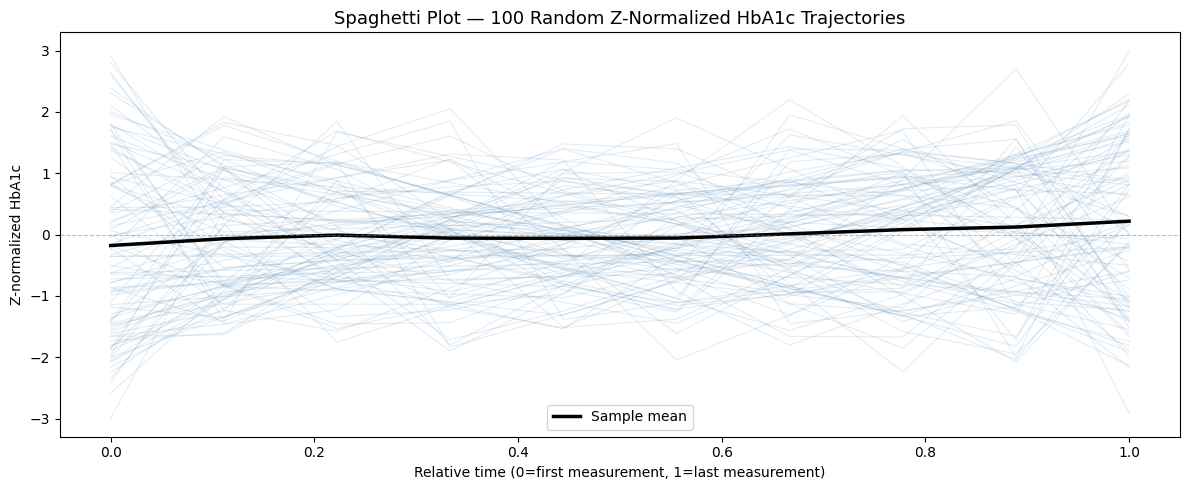

In [ ]:
# --- Plot 2: Spaghetti preview of z-normalized series ---
# A graph to quickly check the overall trend
N_SAMPLE   = min(100, len(patient_ids))
sample_idx = np.random.choice(len(patient_ids), size=N_SAMPLE, replace=False)

fig, ax = plt.subplots(figsize=(12, 5))
for i in sample_idx:
    ax.plot(cluster_grid, X_znorm[i], color='steelblue', alpha=0.15, linewidth=0.8)

ax.plot(cluster_grid, X_znorm[sample_idx].mean(axis=0), color='black', linewidth=2.5, label='Sample mean')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_title(f"Spaghetti Plot — {N_SAMPLE} Random Z-Normalized HbA1c Trajectories", fontsize=13)
ax.set_xlabel("Relative time (0=first measurement, 1=last measurement)")
ax.set_ylabel("Z-normalized HbA1c")
ax.legend()
plt.tight_layout()
plt.show()